In [12]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

In [13]:


# -------------------------------------------------
# Create FrozenLake Environment
# -------------------------------------------------
custom_map = [
    "FFSF",
    "FHFH",
    "FFFH",
    "HGFF"
]
env = gym.make("FrozenLake-v1", is_slippery=True, desc=custom_map)

In [14]:
# -------------------------------------------------
# Hyperparameters
# -------------------------------------------------

num_episodes = 10000
max_steps_per_episode = 100

alpha = 0.1          # Learning rate
gamma = 0.99         # Discount factor

epsilon = 1.0        # Initial exploration rate
epsilon_min = 0.05
epsilon_decay = 0.9995

In [15]:
# -------------------------------------------------
# Initialize Q-table
# -------------------------------------------------

Q = np.zeros((env.observation_space.n, env.action_space.n))

# -------------------------------------------------
# Epsilon-Greedy Action Selection
# -------------------------------------------------

def epsilon_greedy_action(state, epsilon):
    """
    Selects an action using epsilon-greedy strategy.
    """
    if np.random.uniform(0, 1) < epsilon:
        return env.action_space.sample()  # Explore: choose a random action
    else:
        return np.argmax(Q[state, :])    # Exploit: choose the action with max Q-value

In [16]:
# -------------------------------------------------
# SARSA Training
# -------------------------------------------------

episode_rewards = []

for episode in range(num_episodes):
    state, _ = env.reset() # Initial state
    action = epsilon_greedy_action(state, epsilon) # Initial action

    done = False
    truncated = False
    rewards_current_episode = 0

    for step in range(max_steps_per_episode):
        next_state, reward, done, truncated, _ = env.step(action)
        next_action = epsilon_greedy_action(next_state, epsilon) # Select next action using epsilon-greedy

        # SARSA Update Rule
        Q[state, action] = Q[state, action] + alpha * \
                           (reward + gamma * Q[next_state, next_action] - Q[state, action])

        state = next_state
        action = next_action
        rewards_current_episode += reward

        if done or truncated:
            break

    # Epsilon decay
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    episode_rewards.append(rewards_current_episode)


    # Derive state-value function and policy from the learned Q-table
    state_values = np.max(Q, axis=1)
    learned_policy = np.argmax(Q, axis=1)

In [17]:
# -------------------------------------------------
# Display Functions
# -------------------------------------------------

def print_value_function(values):
    print("\nEstimated State-Value Function:")
    print(np.round(values.reshape(4, 4), 3))


def print_policy(policy):
    action_symbols = {
        0: "L",
        1: "D",
        2: "R",
        3: "U"
    }

    policy_grid = np.array(
        [action_symbols[action] for action in policy]
    ).reshape(4, 4)

    print("\nLearned Policy:")
    print(policy_grid)

In [18]:
# -------------------------------------------------
# Output
# -------------------------------------------------

print("\nFinal Q-table:")
print(np.round(Q, 3))

print_value_function(state_values)
print_policy(learned_policy)

average_reward = np.mean(episode_rewards[-1000:])
print("\nAverage reward over last 1000 episodes:", average_reward)


Final Q-table:
[[0.59  0.517 0.538 0.514]
 [0.365 0.311 0.313 0.516]
 [0.424 0.403 0.396 0.439]
 [0.329 0.336 0.253 0.421]
 [0.62  0.437 0.488 0.36 ]
 [0.    0.    0.    0.   ]
 [0.211 0.215 0.396 0.087]
 [0.    0.    0.    0.   ]
 [0.571 0.501 0.469 0.689]
 [0.548 0.792 0.528 0.431]
 [0.716 0.574 0.327 0.406]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.85  0.933 0.811 0.796]
 [0.457 0.88  0.498 0.521]]

Estimated State-Value Function:
[[0.59  0.516 0.439 0.421]
 [0.62  0.    0.396 0.   ]
 [0.689 0.792 0.716 0.   ]
 [0.    0.    0.933 0.88 ]]

Learned Policy:
[['L' 'U' 'U' 'U']
 ['L' 'L' 'R' 'L']
 ['U' 'D' 'L' 'L']
 ['L' 'L' 'D' 'D']]

Average reward over last 1000 episodes: 0.611


NAME: MONISH N
REG NO: 212223240097


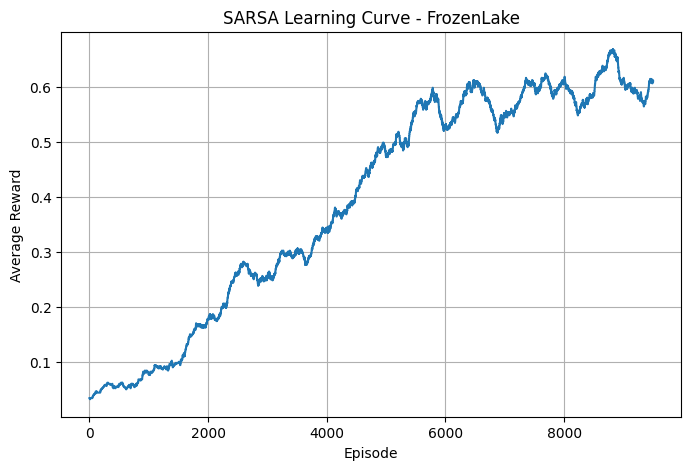

In [20]:
# -------------------------------------------------
# Plot Learning Curve
# -------------------------------------------------

window = 500

moving_average = np.convolve(
    episode_rewards,
    np.ones(window) / window,
    mode="valid"
)
print("NAME: MONISH N")
print("REG NO: 212223240097")
plt.figure(figsize=(8, 5))
plt.plot(moving_average)
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("SARSA Learning Curve - FrozenLake")
plt.grid(True)
plt.show()

env.close()